## Data Import

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
dataset_path = '/content/drive/MyDrive/CSE437_Final_Project/data/'
train_file = 'cell2cell.csv'

Mounted at /content/drive


## Load

In [ ]:
# --- Load Data ---
train_df = pd.read_csv(f'{dataset_path}{train_file}')

# Remove rows where 'Churn' is missing as requested
train_df = train_df.dropna(subset=['Churn'])

print(f"Loaded and filtered data with shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
display(train_df.head())

# --- Data Overview ---
print("\n--- Data Info ---")
print(train_df.info())

Loaded and filtered data with shape: (51047, 58)
Columns: ['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser', 'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMotorcycle', 'AdjustmentsToCr

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047

## Missing Values

In [ ]:
print("\n--- Missing Values Summary ---")
missing_counts = train_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print(missing_counts)
print(f"\nTotal missing values: {missing_counts.sum()}")
print(f"Number of columns with missing values: {len(missing_counts)}")


--- Missing Values Summary ---
AgeHH2                   909
AgeHH1                   909
PercChangeRevenues       367
PercChangeMinutes        367
MonthlyRevenue           156
MonthlyMinutes           156
RoamingCalls             156
OverageMinutes           156
DirectorAssistedCalls    156
TotalRecurringCharge     156
ServiceArea               24
Handsets                   1
CurrentEquipmentDays       1
HandsetModels              1
dtype: int64

Total missing values: 3515
Number of columns with missing values: 14


## Class Distribution

In [ ]:
print("\n--- Target Distribution (Churn) ---")
print(train_df['Churn'].value_counts())
print(f"\nChurn percentage: {train_df['Churn'].value_counts(normalize=True) * 100}")


--- Target Distribution (Churn) ---
Churn
No     36336
Yes    14711
Name: count, dtype: int64

Churn percentage: Churn
No     71.18146
Yes    28.81854
Name: proportion, dtype: float64


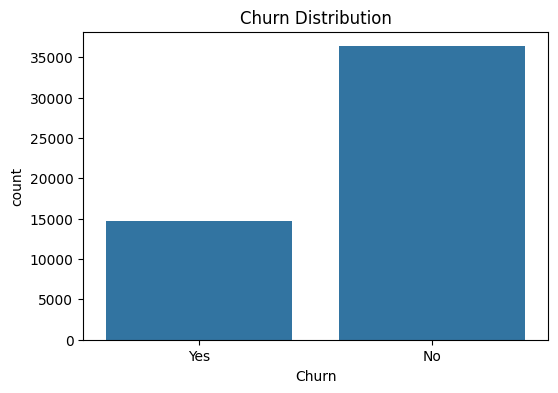

In [ ]:
# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='Churn')
plt.title('Churn Distribution')
plt.show()

## Feature & Target Seperation

In [ ]:
# --- Separate Features and Target ---
X = train_df.drop('Churn', axis=1)
y = train_df['Churn']

## Convert target to binary

In [ ]:
y = y.apply(lambda x: 1 if x == 'Yes' else 0)
print(f"\nTarget converted: 1 = Churn, 0 = No Churn")
print(y.value_counts())


Target converted: 1 = Churn, 0 = No Churn
Churn
0    36336
1    14711
Name: count, dtype: int64


##  Create Hold-out Test Set (20%)

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test_final, y_temp, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n--- Split Shapes ---")
print(f"X_temp (for CV): {X_temp.shape}")
print(f"X_test_final (hold-out): {X_test_final.shape}")
print(f"y_temp: {y_temp.shape}")
print(f"y_test_final: {y_test_final.shape}")

print(f"\n--- Class Distribution in Splits ---")
print(f"Temp set:\n{y_temp.value_counts()}")
print(f"Hold-out test set:\n{y_test_final.value_counts()}")


--- Split Shapes ---
X_temp (for CV): (40837, 57)
X_test_final (hold-out): (10210, 57)
y_temp: (40837,)
y_test_final: (10210,)

--- Class Distribution in Splits ---
Temp set:
Churn
0    29068
1    11769
Name: count, dtype: int64
Hold-out test set:
Churn
0    7268
1    2942
Name: count, dtype: int64


In [ ]:
X = X_temp
y = y_temp

print("\n--- Ready for EDA on X (temp set) ---")
print(f"X shape: {X.shape}")


--- Ready for EDA on X (temp set) ---
X shape: (40837, 57)


## Numerical VS Categorical

In [ ]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

In [ ]:
if 'CustomerID' in numerical_cols:
    numerical_cols.remove('CustomerID')
if 'CustomerID' in categorical_cols:
    categorical_cols.remove('CustomerID')

In [ ]:
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (34): ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating']
Categorical columns (22): ['ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', '

## Outlier Analysis and Capping

### numerical columns, cap outliers at the 99th percentile

In [ ]:
print("\n--- Outlier Capping ---")
capping_thresholds = {}

for col in numerical_cols:
    upper_bound = X[col].quantile(0.99)
    capping_thresholds[col] = upper_bound
    print(f"{col}: 99th percentile = {upper_bound:.2f}")

# Apply capping to X (we'll cap before any other transformations)
X_capped = X.copy()
for col in numerical_cols:
    X_capped[col] = np.where(X_capped[col] > capping_thresholds[col],
                            capping_thresholds[col],
                            X_capped[col])

print("\nOutlier capping applied to numerical columns.")


--- Outlier Capping ---
MonthlyRevenue: 99th percentile = 228.33
MonthlyMinutes: 99th percentile = 2450.00
TotalRecurringCharge: 99th percentile = 120.00
DirectorAssistedCalls: 99th percentile = 9.65
OverageMinutes: 99th percentile = 434.00
RoamingCalls: 99th percentile = 21.58
PercChangeMinutes: 99th percentile = 741.00
PercChangeRevenues: 99th percentile = 117.62
DroppedCalls: 99th percentile = 42.30
BlockedCalls: 99th percentile = 46.30
UnansweredCalls: 99th percentile = 178.70
CustomerCareCalls: 99th percentile = 21.30
ThreewayCalls: 99th percentile = 4.00
ReceivedCalls: 99th percentile = 772.53
OutboundCalls: 99th percentile = 163.00
InboundCalls: 99th percentile = 77.19
PeakCallsInOut: 99th percentile = 493.89
OffPeakCallsInOut: 99th percentile = 435.70
DroppedBlockedCalls: 99th percentile = 71.30
CallForwardingCalls: 99th percentile = 0.00
CallWaitingCalls: 99th percentile = 22.30
MonthsInService: 99th percentile = 49.00
UniqueSubs: 99th percentile = 5.00
ActiveSubs: 99th perce

### EDA: Numerical Feature Distributions (After Capping)

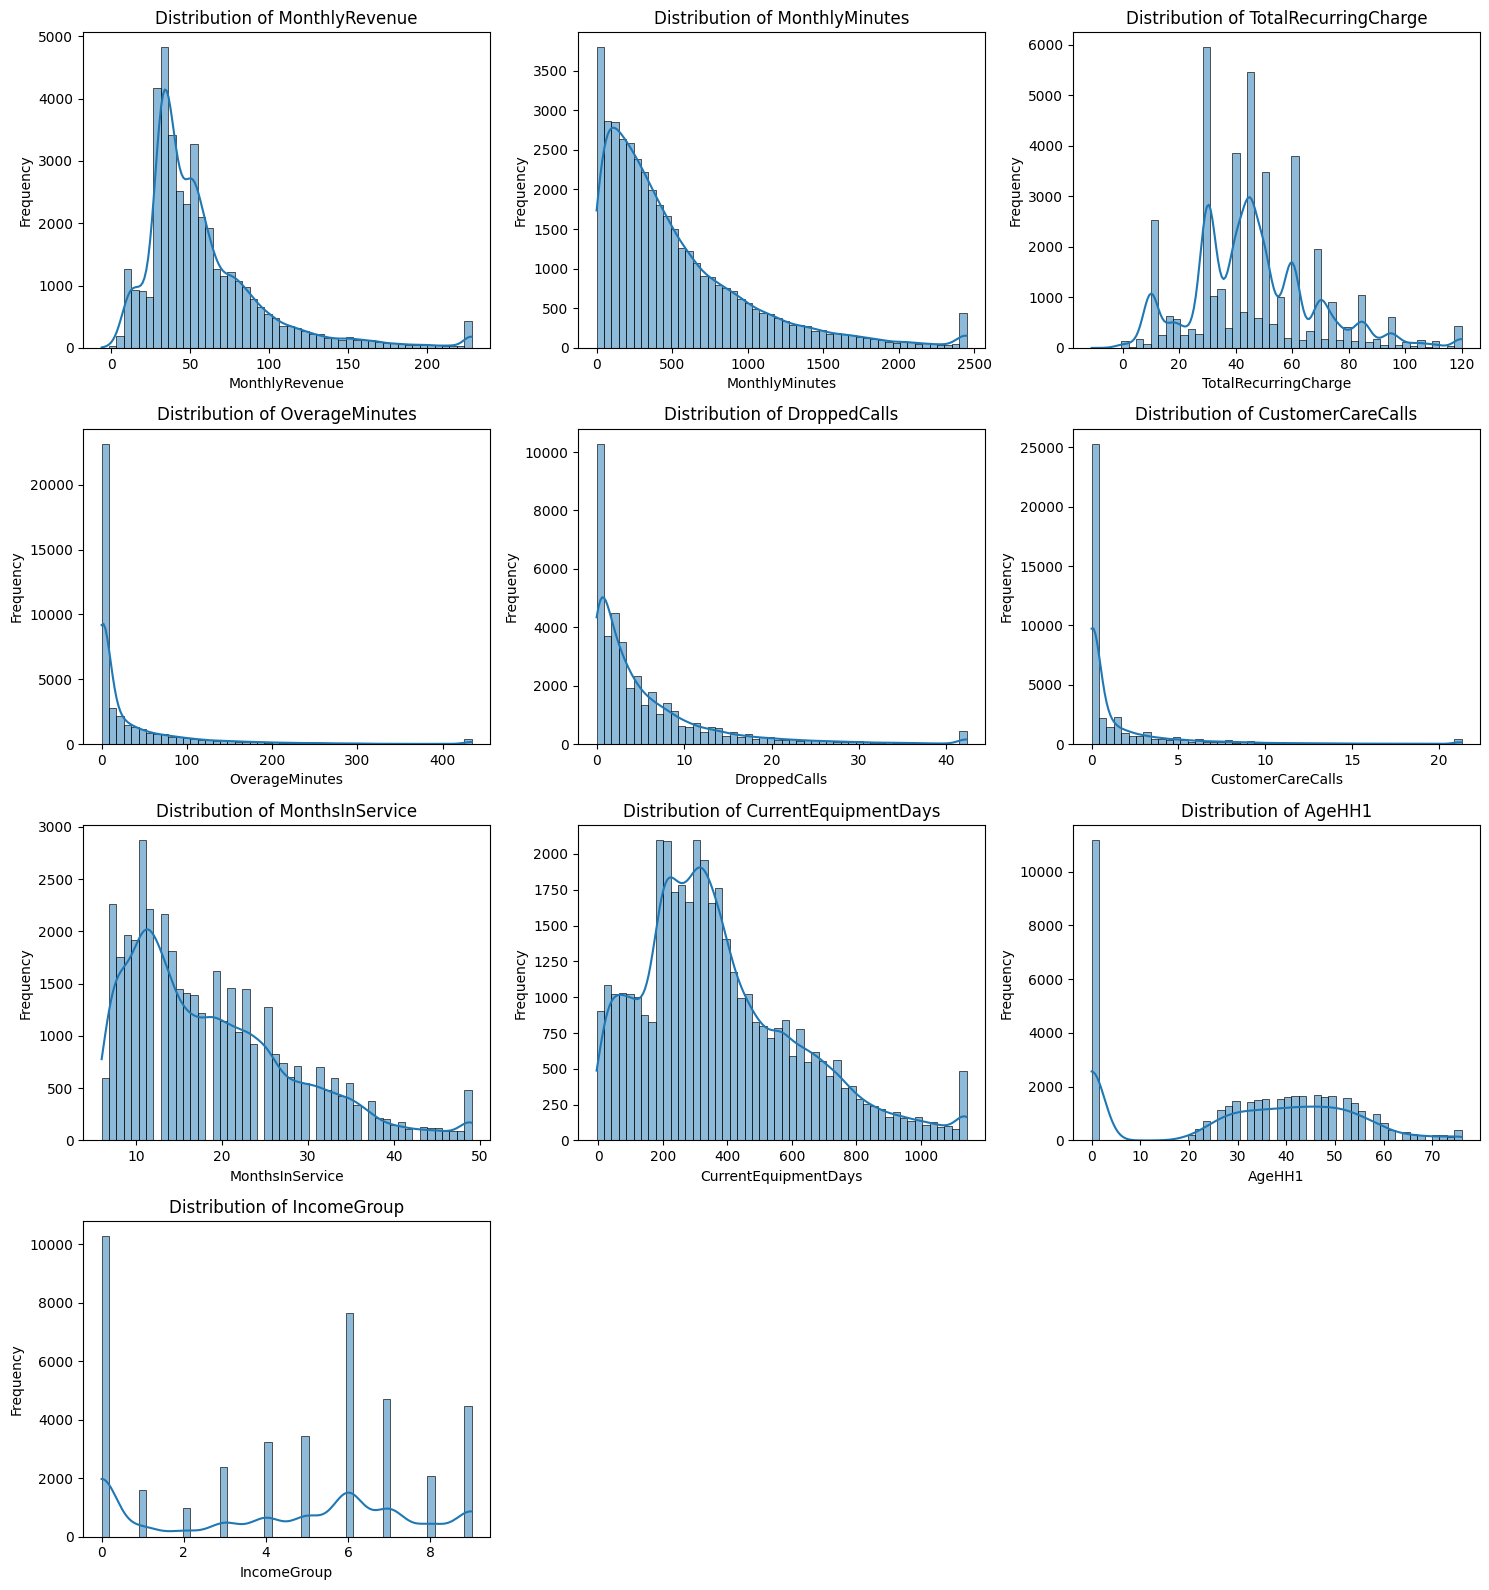

In [ ]:
num_cols_to_plot = ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
                    'OverageMinutes', 'DroppedCalls', 'CustomerCareCalls',
                    'MonthsInService', 'CurrentEquipmentDays', 'AgeHH1', 'IncomeGroup']

# Filter to only existing columns
num_cols_to_plot = [col for col in num_cols_to_plot if col in X_capped.columns]

if num_cols_to_plot:
    n_plots = len(num_cols_to_plot)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    for i, col in enumerate(num_cols_to_plot, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(X_capped[col].dropna(), kde=True, bins=50)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### EDA: Categorical Feature Distribution

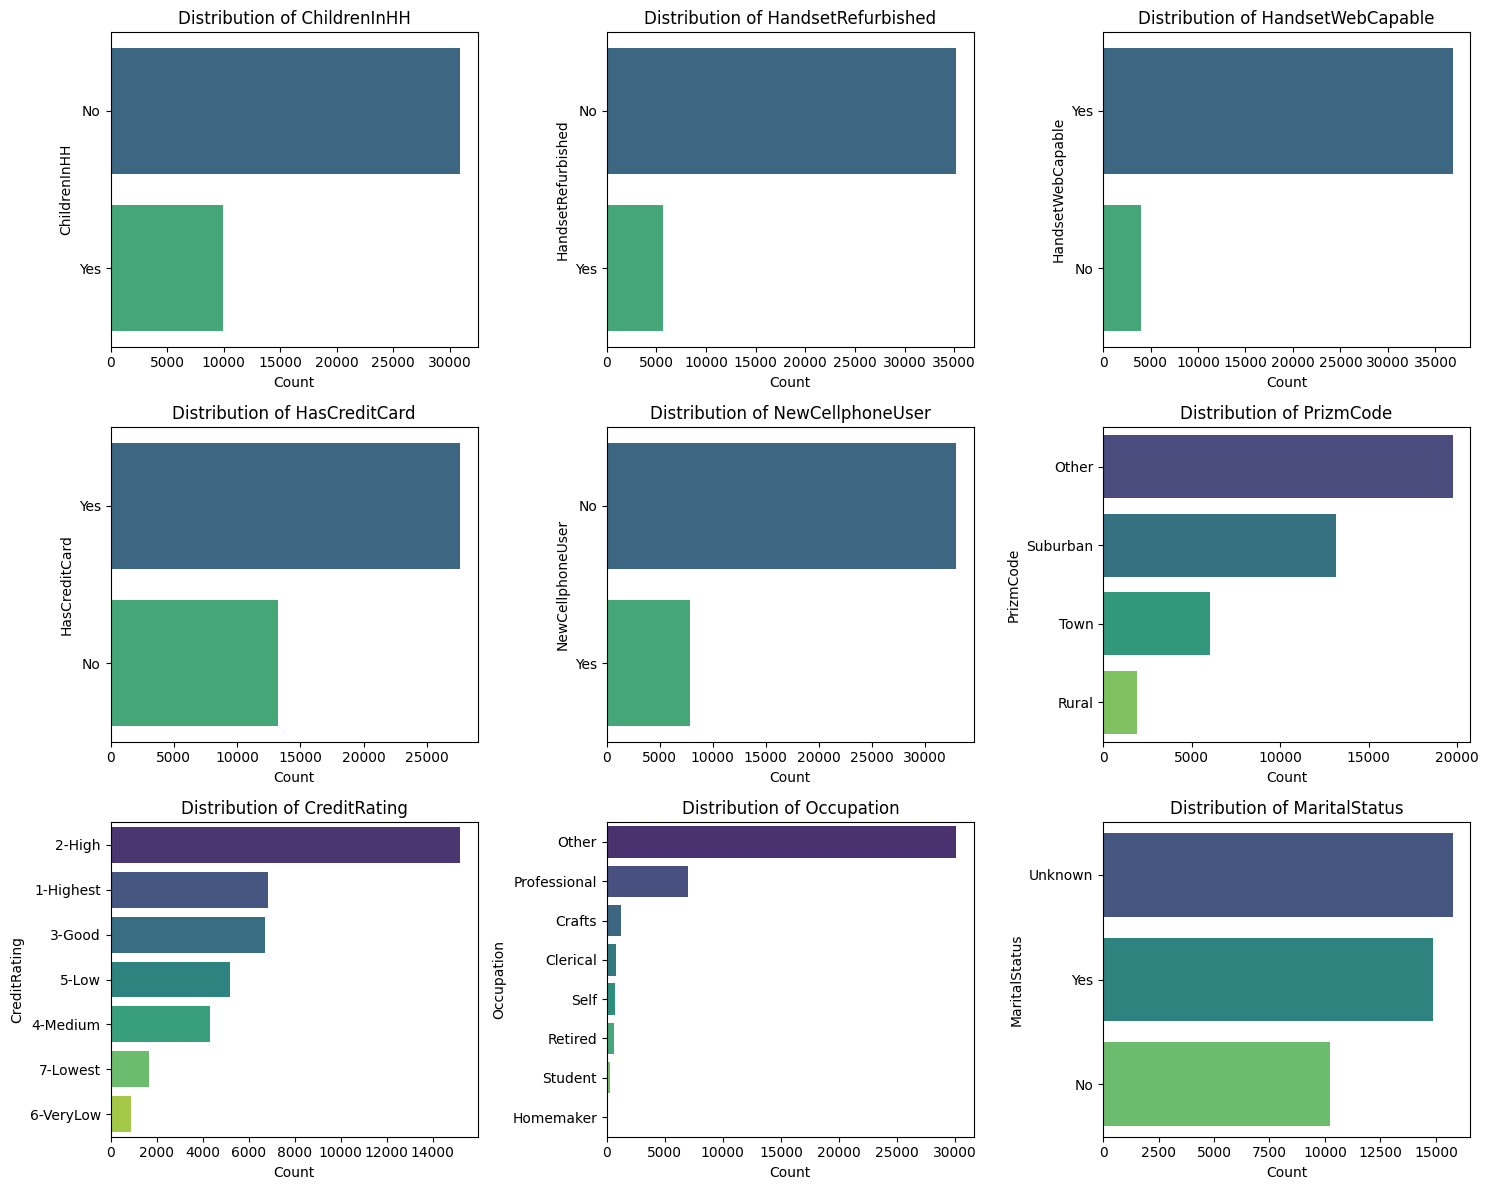

In [ ]:
cat_cols_to_plot = ['ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable',
                   'HasCreditCard', 'NewCellphoneUser', 'PrizmCode',
                   'CreditRating', 'Occupation', 'MaritalStatus']

# Filter to only existing columns
cat_cols_to_plot = [col for col in cat_cols_to_plot if col in X_capped.columns]

if cat_cols_to_plot:
    n_plots = len(cat_cols_to_plot)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    for i, col in enumerate(cat_cols_to_plot, 1):
        plt.subplot(n_rows, n_cols, i)
        # Get value counts and sort for better visualization
        value_counts = X_capped[col].value_counts()
        sns.barplot(x=value_counts.values, y=value_counts.index, palette='viridis')
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## EDA: Correlation Heatmap

### numerical columns for correlation

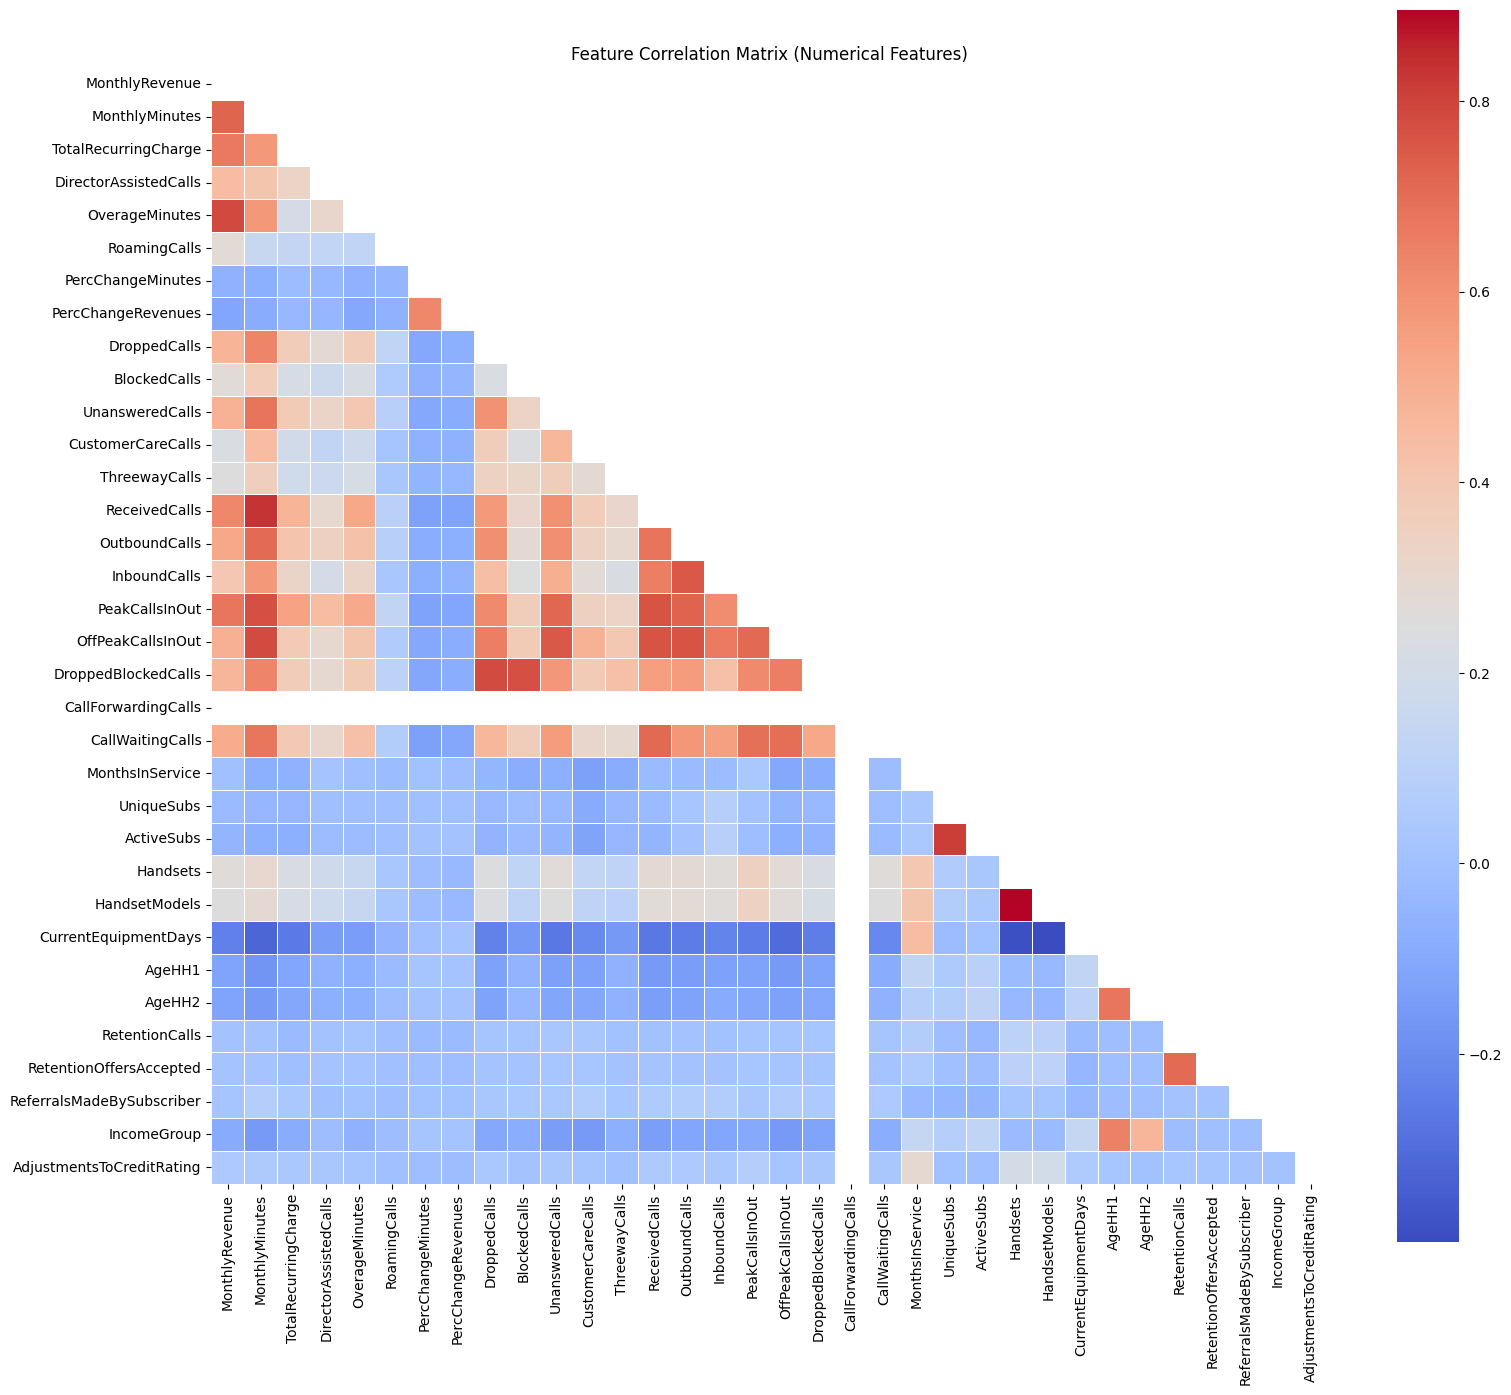


--- Highly Correlated Features (|correlation| > 0.8) ---
MonthlyMinutes & ReceivedCalls: 0.833
UniqueSubs & ActiveSubs: 0.813
Handsets & HandsetModels: 0.896

--- Summary after EDA ---
X shape: (40837, 57)
Numerical columns: 34
Categorical columns: 22


In [ ]:
num_cols_for_corr = numerical_cols.copy()
# Remove columns that might not be useful for correlation
cols_to_remove = ['CustomerID']
num_cols_for_corr = [col for col in num_cols_for_corr if col not in cols_to_remove]

# Calculate correlation matrix
corr_matrix = X_capped[num_cols_for_corr].corr()

plt.figure(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix (Numerical Features)')
plt.show()

# --- Check for Highly Correlated Features ---
print("\n--- Highly Correlated Features (|correlation| > 0.8) ---")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i],
                                   corr_matrix.columns[j],
                                   corr_matrix.iloc[i, j]))

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair[0]} & {pair[1]}: {pair[2]:.3f}")
else:
    print("No highly correlated features found.")

print(f"\n--- Summary after EDA ---")
print(f"X shape: {X_capped.shape}")
print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

##  Missing Data Analysis

In [ ]:
print("\n--- Missing Values After Outlier Capping ---")
missing_counts = X_capped.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print(missing_counts)
print(f"\nTotal missing values: {missing_counts.sum()}")
print(f"Columns with missing values: {len(missing_counts)}")


--- Missing Values After Outlier Capping ---
AgeHH2                   716
AgeHH1                   716
PercChangeRevenues       290
PercChangeMinutes        290
MonthlyRevenue           120
MonthlyMinutes           120
RoamingCalls             120
OverageMinutes           120
DirectorAssistedCalls    120
TotalRecurringCharge     120
ServiceArea               21
Handsets                   1
CurrentEquipmentDays       1
HandsetModels              1
dtype: int64

Total missing values: 2756
Columns with missing values: 14


In [ ]:
X_capped['HandsetPrice'] = pd.to_numeric(X_capped['HandsetPrice'], errors='coerce')
print(f"\nHandsetPrice converted to numeric. Missing values: {X_capped['HandsetPrice'].isnull().sum()}")


HandsetPrice converted to numeric. Missing values: 23214


In [ ]:
demographic_numerical_cols = ['AgeHH1', 'AgeHH2', 'IncomeGroup']
# Other numerical columns (excluding demographic and CustomerID)
other_numerical_cols = [col for col in numerical_cols if col not in demographic_numerical_cols]
# Categorical columns (excluding CustomerID)
categorical_cols_for_impute = [col for col in categorical_cols if col != 'CustomerID']

print(f"\n--- Column Groups for Imputation ---")
print(f"Demographic numerical cols: {demographic_numerical_cols}")
print(f"Other numerical cols: {len(other_numerical_cols)}")
print(f"Categorical cols: {len(categorical_cols_for_impute)}")


--- Column Groups for Imputation ---
Demographic numerical cols: ['AgeHH1', 'AgeHH2', 'IncomeGroup']
Other numerical cols: 31
Categorical cols: 22


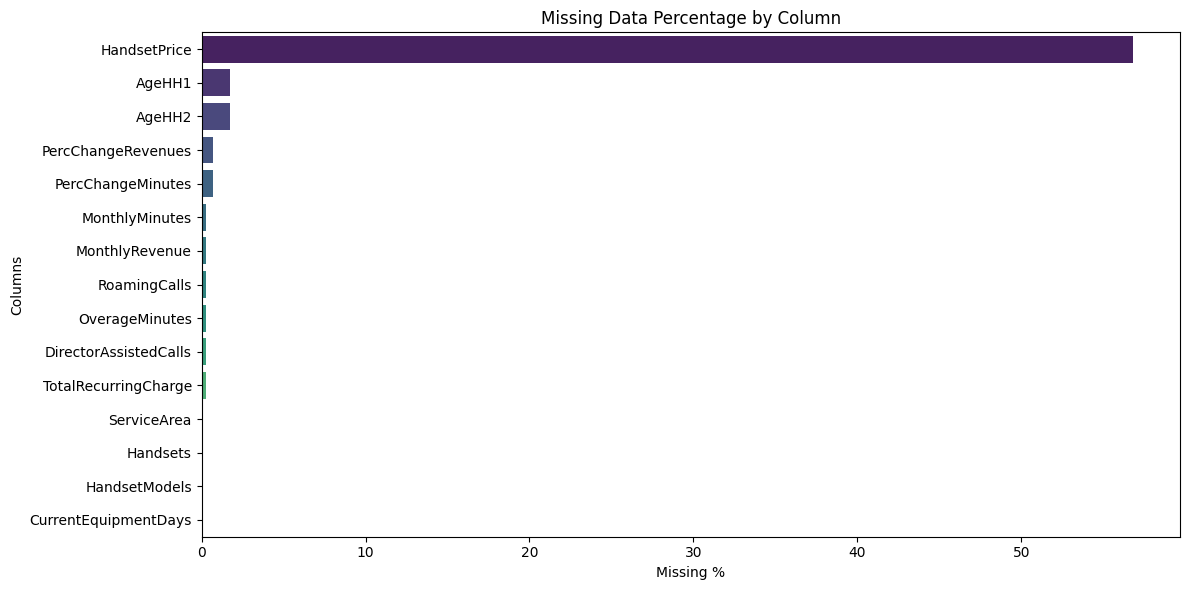

In [ ]:
plt.figure(figsize=(12, 6))
missing_percentage = (X_capped.isnull().sum() / len(X_capped)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
sns.barplot(x=missing_percentage.values, y=missing_percentage.index, palette='viridis')
plt.title('Missing Data Percentage by Column')
plt.xlabel('Missing %')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

## Imputation

In [ ]:
from sklearn.impute import KNNImputer, SimpleImputer

print("\n--- Applying Imputation ---")

# 1. Demographic Numerical Features: KNN Imputation
print("1. Imputing demographic numerical columns with KNN...")
knn_imputer = KNNImputer(n_neighbors=5)
X_imputed = X_capped.copy()
X_imputed[demographic_numerical_cols] = knn_imputer.fit_transform(X_imputed[demographic_numerical_cols])

# 2. Other Numerical Features: Median Imputation
print("2. Imputing other numerical columns with median...")
median_imputer = SimpleImputer(strategy='median')
X_imputed[other_numerical_cols] = median_imputer.fit_transform(X_imputed[other_numerical_cols])

# 3. Categorical Features: Mode Imputation
print("3. Imputing categorical columns with mode...")
mode_imputer = SimpleImputer(strategy='most_frequent')
X_imputed[categorical_cols_for_impute] = mode_imputer.fit_transform(X_imputed[categorical_cols_for_impute])


--- Applying Imputation ---
1. Imputing demographic numerical columns with KNN...
2. Imputing other numerical columns with median...
3. Imputing categorical columns with mode...


In [ ]:
remaining_missing = X_imputed.isnull().sum().sum()
print(f"\nRemaining missing values after imputation: {remaining_missing}")

if remaining_missing == 0:
    print("All missing values have been successfully imputed!")
else:
    print("Some missing values remain. Let's investigate:")
    print(X_imputed.isnull().sum()[X_imputed.isnull().sum() > 0])


Remaining missing values after imputation: 0
All missing values have been successfully imputed!


## Duplicates Handled

In [ ]:
print("\n--- Duplicate Check ---")
duplicates_count = X_imputed.duplicated().sum()
print(f"Duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    print("Removing duplicates...")
    # Keep the first occurrence of each duplicate
    X_imputed = X_imputed.drop_duplicates(keep='first')
    # Reset index
    X_imputed = X_imputed.reset_index(drop=True)
    # Also need to align y with the new X indices
    y_clean = y.iloc[X_imputed.index].reset_index(drop=True)
    print(f"New X shape after removing duplicates: {X_imputed.shape}")
    print(f"New y shape after removing duplicates: {y_clean.shape}")
else:
    y_clean = y.reset_index(drop=True)


--- Duplicate Check ---
Duplicate rows found: 0


In [ ]:
print(f"\n--- Final Alignment Check ---")
print(f"X_imputed shape: {X_imputed.shape}")
print(f"y_clean shape: {y_clean.shape}")

if X_imputed.shape[0] == y_clean.shape[0]:
    print("X and y are aligned!")
else:
    print("X and y are NOT aligned. Please check.")


--- Final Alignment Check ---
X_imputed shape: (40837, 57)
y_clean shape: (40837,)
X and y are aligned!


## Clean Data Extraction

In [ ]:
print("\n--- Saving Cleaned Data ---")
X_imputed.to_csv(f'{dataset_path}X_cleaned.csv', index=False)
y_clean.to_csv(f'{dataset_path}y_cleaned.csv', index=False)
print(f"Saved X_cleaned.csv and y_cleaned.csv to {dataset_path}")

print(f"\n--- Final Summary ---")
print(f"X_imputed shape: {X_imputed.shape}")
print(f"Feature count: {X_imputed.shape[1]}")
print(f"y_clean shape: {y_clean.shape}")
print(f"Class distribution in y_clean:\n{y_clean.value_counts()}")


--- Saving Cleaned Data ---
Saved X_cleaned.csv and y_cleaned.csv to /content/drive/MyDrive/CSE437_Final_Project/data/

--- Final Summary ---
X_imputed shape: (40837, 57)
Feature count: 57
y_clean shape: (40837,)
Class distribution in y_clean:
Churn
0    29068
1    11769
Name: count, dtype: int64


## Variations Of Data: With and Without Highly Correlated Features.

In [ ]:
# --- Load the cleaned data we just saved ---
print("\n--- Loading Cleaned Data ---")
X_cleaned = pd.read_csv(f'{dataset_path}X_cleaned.csv')
y_cleaned = pd.read_csv(f'{dataset_path}y_cleaned.csv')

print(f"Loaded X_cleaned shape: {X_cleaned.shape}")
print(f"Loaded y_cleaned shape: {y_cleaned.shape}")

# ============================================
# Version 1: Keep ALL features (including correlated ones)
# ============================================
print("\ Version 1: ALL features (including correlated ones)")
X_version1 = X_cleaned.copy()
y_version1 = y_cleaned.copy()

# Save Version 1
X_version1.to_csv(f'{dataset_path}X_version1_all_features.csv', index=False)
y_version1.to_csv(f'{dataset_path}y_version1_all_features.csv', index=False)
print(f" Version 1 saved: {X_version1.shape} features")

# ============================================
# Version 2: Remove highly correlated features
# ============================================
print("\ Version 2: REMOVE highly correlated features")
X_version2 = X_cleaned.copy()
y_version2 = y_cleaned.copy()

# Remove the 3 highly correlated features
features_to_remove = ['ReceivedCalls', 'UniqueSubs', 'HandsetModels']
X_version2 = X_version2.drop(columns=features_to_remove, errors='ignore')

print(f"Removed features: {features_to_remove}")
print(f"Features remaining: {X_version2.shape[1]}")

# Save Version 2
X_version2.to_csv(f'{dataset_path}X_version2_no_corr.csv', index=False)
y_version2.to_csv(f'{dataset_path}y_version2_no_corr.csv', index=False)
print(f" Version 2 saved: {X_version2.shape[1]} features")

# ============================================
# Summary
# ============================================
print("\n" + "="*60)
print("DATA EXPORT SUMMARY")
print("="*60)

print(f"\n Dataset saved to: {dataset_path}")

print("\ Version 1: ALL features (including correlated ones)")
print(f"   - Features: {X_version1.shape[1]}")
print(f"   - Rows: {X_version1.shape[0]}")
print(f"   - Files: X_version1_all_features.csv, y_version1_all_features.csv")

print("\ Version 2: WITHOUT highly correlated features")
print(f"   - Features: {X_version2.shape[1]}")
print(f"   - Rows: {X_version2.shape[0]}")
print(f"   - Files: X_version2_no_corr.csv, y_version2_no_corr.csv")

print("\n Removed features (Version 2):")
print("   - ReceivedCalls (correlated with MonthlyMinutes at 0.837)")
print("   - UniqueSubs (correlated with ActiveSubs at 0.811)")
print("   - HandsetModels (correlated with Handsets at 0.895)")

print("\n Both versions are ready for modeling in Notebook 2!")
print("="*60)


--- Loading Cleaned Data ---
Loaded X_cleaned shape: (40837, 57)
Loaded y_cleaned shape: (40837, 1)
\ Version 1: ALL features (including correlated ones)
 Version 1 saved: (40837, 57) features
\ Version 2: REMOVE highly correlated features
Removed features: ['ReceivedCalls', 'UniqueSubs', 'HandsetModels']
Features remaining: 54
 Version 2 saved: 54 features

DATA EXPORT SUMMARY

 Dataset saved to: /content/drive/MyDrive/CSE437_Final_Project/data/
\ Version 1: ALL features (including correlated ones)
   - Features: 57
   - Rows: 40837
   - Files: X_version1_all_features.csv, y_version1_all_features.csv
\ Version 2: WITHOUT highly correlated features
   - Features: 54
   - Rows: 40837
   - Files: X_version2_no_corr.csv, y_version2_no_corr.csv

 Removed features (Version 2):
   - ReceivedCalls (correlated with MonthlyMinutes at 0.837)
   - UniqueSubs (correlated with ActiveSubs at 0.811)
   - HandsetModels (correlated with Handsets at 0.895)

 Both versions are ready for modeling in Note

## Held-Out Test Set (Final) Analysis and Preprocessing

First, let's look at the shape and initial missing values in the held-out test set (`X_test_final`, `y_test_final`).

In [ ]:
print(f"\n--- Held-Out Test Set (X_test_final) Initial Info ---")
print(f"X_test_final shape: {X_test_final.shape}")
print(f"y_test_final shape: {y_test_final.shape}")

# Display missing values in X_test_final
missing_counts_test = X_test_final.isnull().sum()
missing_counts_test = missing_counts_test[missing_counts_test > 0].sort_values(ascending=False)
print("\nMissing values in X_test_final before processing:")
print(missing_counts_test)
print(f"Total missing values in X_test_final: {missing_counts_test.sum()}")

# Display missing values in y_test_final (should be none as it's the target)
print("\nMissing values in y_test_final:")
print(y_test_final.isnull().sum())


--- Held-Out Test Set (X_test_final) Initial Info ---
X_test_final shape: (10210, 57)
y_test_final shape: (10210,)

Missing values in X_test_final before processing:
AgeHH1                   193
AgeHH2                   193
PercChangeMinutes         77
PercChangeRevenues        77
TotalRecurringCharge      36
MonthlyRevenue            36
MonthlyMinutes            36
RoamingCalls              36
OverageMinutes            36
DirectorAssistedCalls     36
ServiceArea                3
dtype: int64
Total missing values in X_test_final: 759

Missing values in y_test_final:
0


Now, we apply the same preprocessing steps to `X_test_final` as we did to the training data. This includes:
1. Converting `HandsetPrice` to numeric.
2. Capping outliers using the thresholds learned from the training data.
3. Imputing missing values using imputers fitted on the training data.

In [ ]:
# Make a copy to avoid modifying the original X_test_final
X_test_processed = X_test_final.copy()

# 1. Convert HandsetPrice to numeric (same as training data)
X_test_processed['HandsetPrice'] = pd.to_numeric(X_test_processed['HandsetPrice'], errors='coerce')
print(f"\nHandsetPrice converted to numeric. Missing values in X_test_processed: {X_test_processed['HandsetPrice'].isnull().sum()}")

# 2. Apply Capping to X_test_processed using thresholds from training data
print("\n--- Applying Outlier Capping to X_test_processed ---")
for col in numerical_cols:
    if col in X_test_processed.columns and col in capping_thresholds:
        X_test_processed[col] = np.where(X_test_processed[col] > capping_thresholds[col],
                                         capping_thresholds[col],
                                         X_test_processed[col])
print("Outlier capping applied to numerical columns in X_test_processed.")

# 3. Impute Missing Values in X_test_processed
print("\n--- Applying Imputation to X_test_processed ---")

# Re-fit imputers on the *training data* (X_capped) and then transform X_test_processed

# Demographic Numerical Features: KNN Imputation
# Ensure the imputer is fitted on the training data (X_capped before its own imputation)
knn_imputer_test = KNNImputer(n_neighbors=5)
# Fit on training data (X_capped) then transform test data
knn_imputer_test.fit(X_capped[demographic_numerical_cols])
X_test_processed[demographic_numerical_cols] = knn_imputer_test.transform(X_test_processed[demographic_numerical_cols])
print("Demographic numerical columns imputed with KNN (fitted on training data).")

# Other Numerical Features: Median Imputation
median_imputer_test = SimpleImputer(strategy='median')
median_imputer_test.fit(X_capped[other_numerical_cols]) # Fit on training data
X_test_processed[other_numerical_cols] = median_imputer_test.transform(X_test_processed[other_numerical_cols])
print("Other numerical columns imputed with median (fitted on training data).")

# Categorical Features: Mode Imputation
mode_imputer_test = SimpleImputer(strategy='most_frequent')
mode_imputer_test.fit(X_capped[categorical_cols_for_impute]) # Fit on training data
X_test_processed[categorical_cols_for_impute] = mode_imputer_test.transform(X_test_processed[categorical_cols_for_impute])
print("Categorical columns imputed with mode (fitted on training data).")


# Verify no missing values remain
remaining_missing_test = X_test_processed.isnull().sum().sum()
print(f"\nRemaining missing values in X_test_processed after imputation: {remaining_missing_test}")
if remaining_missing_test == 0:
    print("All missing values in X_test_processed have been successfully imputed!")
else:
    print("Some missing values remain. Let's investigate:")
    print(X_test_processed.isnull().sum()[X_test_processed.isnull().sum() > 0])


HandsetPrice converted to numeric. Missing values in X_test_processed: 5768

--- Applying Outlier Capping to X_test_processed ---
Outlier capping applied to numerical columns in X_test_processed.

--- Applying Imputation to X_test_processed ---
Demographic numerical columns imputed with KNN (fitted on training data).
Other numerical columns imputed with median (fitted on training data).
Categorical columns imputed with mode (fitted on training data).

Remaining missing values in X_test_processed after imputation: 0
All missing values in X_test_processed have been successfully imputed!


Now, let's check for duplicate rows in the processed held-out test set.

In [ ]:
print("\n--- Duplicate Check for X_test_processed ---")
duplicates_count_test = X_test_processed.duplicated().sum()
print(f"Duplicate rows found in X_test_processed: {duplicates_count_test}")

if duplicates_count_test > 0:
    print("Removing duplicates from X_test_processed...")
    # Keep the first occurrence of each duplicate
    X_test_processed = X_test_processed.drop_duplicates(keep='first')
    # Reset index
    X_test_processed = X_test_processed.reset_index(drop=True)
    # Also need to align y_test_final with the new X_test_processed indices
    y_test_processed = y_test_final.iloc[X_test_processed.index].reset_index(drop=True)
    print(f"New X_test_processed shape after removing duplicates: {X_test_processed.shape}")
    print(f"New y_test_processed shape after removing duplicates: {y_test_processed.shape}")
else:
    y_test_processed = y_test_final.reset_index(drop=True)
    print("No duplicates found or removed from X_test_processed.")

print(f"\n--- Final Alignment Check for Test Set ---")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"y_test_processed shape: {y_test_processed.shape}")

if X_test_processed.shape[0] == y_test_processed.shape[0]:
    print("X_test_processed and y_test_processed are aligned!")
else:
    print("X_test_processed and y_test_processed are NOT aligned. Please check.")


--- Duplicate Check for X_test_processed ---
Duplicate rows found in X_test_processed: 0
No duplicates found or removed from X_test_processed.

--- Final Alignment Check for Test Set ---
X_test_processed shape: (10210, 57)
y_test_processed shape: (10210,)
X_test_processed and y_test_processed are aligned!


### Class Distribution in the Cleaned Held-Out Test Set


--- Target Distribution (Churn) in Cleaned Held-Out Test Set ---
Churn
0    7268
1    2942
Name: count, dtype: int64

Churn percentage:
Churn
0    71.185113
1    28.814887
Name: proportion, dtype: float64


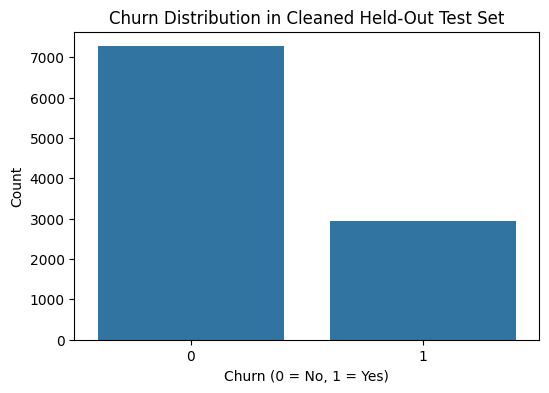

In [ ]:
print("\n--- Target Distribution (Churn) in Cleaned Held-Out Test Set ---")
print(y_test_processed.value_counts())
print(f"\nChurn percentage:\n{y_test_processed.value_counts(normalize=True) * 100}")

# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_test_processed)
plt.title('Churn Distribution in Cleaned Held-Out Test Set')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Finally, we save the cleaned held-out test set to CSV files. We will create two versions, similar to the training data:
1. **Version 1**: All features (including correlated ones).
2. **Version 2**: With highly correlated features removed (based on the analysis of the training data).

In [ ]:
print("\n--- Saving Cleaned Held-Out Test Data ---")

# ============================================
# Version 1: Keep ALL features (including correlated ones)
# ============================================
X_test_version1 = X_test_processed.copy()
y_test_version1 = y_test_processed.copy()

X_test_version1.to_csv(f'{dataset_path}X_test_version1_all_features.csv', index=False)
y_test_version1.to_csv(f'{dataset_path}y_test_version1_all_features.csv', index=False)
print(f"Version 1 (all features) saved: {X_test_version1.shape[1]} features, {X_test_version1.shape[0]} rows")

# ============================================
# Version 2: Remove highly correlated features (same features as training set)
# ============================================
X_test_version2 = X_test_processed.copy()
y_test_version2 = y_test_processed.copy()

# Features to remove are based on training data correlation analysis
features_to_remove_test = ['ReceivedCalls', 'UniqueSubs', 'HandsetModels']
X_test_version2 = X_test_version2.drop(columns=features_to_remove_test, errors='ignore')

X_test_version2.to_csv(f'{dataset_path}X_test_version2_no_corr.csv', index=False)
y_test_version2.to_csv(f'{dataset_path}y_test_version2_no_corr.csv', index=False)
print(f"Version 2 (no correlated features) saved: {X_test_version2.shape[1]} features, {X_test_version2.shape[0]} rows")

print("\nCleaned held-out test sets are ready for model evaluation!")


--- Saving Cleaned Held-Out Test Data ---
Version 1 (all features) saved: 57 features, 10210 rows
Version 2 (no correlated features) saved: 54 features, 10210 rows

Cleaned held-out test sets are ready for model evaluation!


## New Held-Out Test Sets: Rows with Missing Values/Type Errors Removed Directly (No Imputation)

In [ ]:
# Load the original X_test_final and y_test_final (from initial split, before any processing)
# Ensure we use the raw versions for this direct drop approach
X_test_final_raw = X_test_final.copy() # X_test_final is from cell Qcv3w5xJil8T
y_test_final_raw = y_test_final.copy() # y_test_final is from cell Qcv3w5xJil8T

print("--- Creating Held-Out Test Sets by Dropping Rows ---")
print(f"Initial raw X_test_final shape: {X_test_final_raw.shape}")
print(f"Initial raw y_test_final shape: {y_test_final_raw.shape}")

# 1. Convert HandsetPrice to numeric, coercing errors to NaN
X_test_final_raw['HandsetPrice'] = pd.to_numeric(X_test_final_raw['HandsetPrice'], errors='coerce')
print(f"\nHandsetPrice converted to numeric. New NaNs: {X_test_final_raw['HandsetPrice'].isnull().sum()}")

# Identify rows with any missing values (original NaNs + HandsetPrice coercions)
missing_rows_mask = X_test_final_raw.isnull().any(axis=1)
num_rows_to_drop = missing_rows_mask.sum()

print(f"\nNumber of rows with missing values (including HandsetPrice errors): {num_rows_to_drop}")

# Drop rows with missing values from both X and y
X_test_dropped = X_test_final_raw[~missing_rows_mask].reset_index(drop=True)
y_test_dropped = y_test_final_raw[~missing_rows_mask].reset_index(drop=True)

print(f"X_test_dropped shape after removing rows: {X_test_dropped.shape}")
print(f"y_test_dropped shape after removing rows: {y_test_dropped.shape}")

# Verify no missing values remain
remaining_missing_dropped = X_test_dropped.isnull().sum().sum()
print(f"Remaining missing values in X_test_dropped: {remaining_missing_dropped}")

# ============================================
# Version 1 (No Imputation): All features
# ============================================
X_test_no_impute_version1 = X_test_dropped.copy()
y_test_no_impute_version1 = y_test_dropped.copy()

X_test_no_impute_version1.to_csv(f'{dataset_path}X_test_no_impute_version1_all_features.csv', index=False)
y_test_no_impute_version1.to_csv(f'{dataset_path}y_test_no_impute_version1_all_features.csv', index=False)
print(f"\nVersion 1 (no imputation, all features) saved: {X_test_no_impute_version1.shape[1]} features, {X_test_no_impute_version1.shape[0]} rows")

# ============================================
# Version 2 (No Imputation, No Correlation):
# Remove highly correlated features (same as training set logic)
# ============================================
X_test_no_impute_version2 = X_test_dropped.copy()
y_test_no_impute_version2 = y_test_dropped.copy()

features_to_remove_for_no_corr = ['ReceivedCalls', 'UniqueSubs', 'HandsetModels'] # Identified during training EDA
X_test_no_impute_version2 = X_test_no_impute_version2.drop(columns=features_to_remove_for_no_corr, errors='ignore')

X_test_no_impute_version2.to_csv(f'{dataset_path}X_test_no_impute_version2_no_corr.csv', index=False)
y_test_no_impute_version2.to_csv(f'{dataset_path}y_test_no_impute_version2_no_corr.csv', index=False)
print(f"Version 2 (no imputation, no correlated features) saved: {X_test_no_impute_version2.shape[1]} features, {X_test_no_impute_version2.shape[0]} rows")

print("\nNew held-out test sets (with missing rows dropped) are ready for model evaluation!")

--- Creating Held-Out Test Sets by Dropping Rows ---
Initial raw X_test_final shape: (10210, 57)
Initial raw y_test_final shape: (10210,)

HandsetPrice converted to numeric. New NaNs: 5768

Number of rows with missing values (including HandsetPrice errors): 5890
X_test_dropped shape after removing rows: (4320, 57)
y_test_dropped shape after removing rows: (4320,)
Remaining missing values in X_test_dropped: 0

Version 1 (no imputation, all features) saved: 57 features, 4320 rows
Version 2 (no imputation, no correlated features) saved: 54 features, 4320 rows

New held-out test sets (with missing rows dropped) are ready for model evaluation!
